In [3]:
import numpy as np
import scipy.linalg as LA
# sparse simulation
import scipy.sparse as sp
import scipy.sparse.linalg as spla
# from numpy import linalg as LA
import matplotlib.pyplot as plt
from scipy.integrate import quad_vec
import os
import pickle
import matplotlib.cm as cm
from scipy.optimize import root
from cmath import *


In [9]:
 '''
  rc( 'font' , **{ 'family':  'serif ’ , ’ serif ’:[ ’Palatino ’]})
   don't forget:
   source ~/venvs/qsim/bin/activate 
    when you are done --> deactivate
 python -m jupyter notebook
 change kernel to Python 3.11 (qsim)
  python -m pip install sympy
 '''


"\n rc( 'font' , **{ 'family':  'serif ’ , ’ serif ’:[ ’Palatino ’]})\n  don't forget:\n  source ~/venvs/qsim/bin/activate \n   when you are done --> deactivate\npython -m jupyter notebook\nchange kernel to Python 3.11 (qsim)\n python -m pip install sympy\n"

In [4]:
import sys
print("Python exe:", sys.executable)
try:
    import ssl
    import OpenSSL  # may fail if not installed; that's OK
    print("ssl OK")
except Exception as e:
    print("ssl import failed:", repr(e))


Python exe: /Users/juan/venvs/qsim/bin/python
ssl import failed: ModuleNotFoundError("No module named 'OpenSSL'")


In [5]:
def ensure_directory_exists(home):
    if not os.path.exists(home):
        os.makedirs(home)

In [7]:
def Hamiltonian(L, t1, mu=0.0, bc="open", dtype=np.complex128):
    """
    Nearest-neighbor Hamiltonian H = mu*I + t1*sum_j (|j><j+1| + |j+1><j|)
    on a chain of length N = 2*L.  OBC/PBC supported. Sparse CSR.
    """
    N = 2*L
    main = mu * np.ones(N, dtype=dtype)
    off  = -t1 * np.ones(N-1, dtype=dtype)

    # OBC tridiagonal
    H = sp.diags([off, main, off], offsets=[-1, 0, 1], format="csr", dtype=dtype)

    if bc.lower() == "periodic" or bc.lower() == "pbc":
        # add wrap bonds
        H = H.tolil()
        H[0,  N-1] = t1
        H[N-1, 0]  = t1
        H = H.tocsr()

    return H

In [10]:
#Inhomogeneous initial state
def Gamma_0(L):
    unit= L
    n1= np.array([[0,0],[0,1]])
    rho_0L= np.zeros([2*L,2*L]) #Left side is the vacuum
    nell_indices= np.array([0 if i%2 ==0 else 1 for i in range(unit)])
    rho_0R= np.kron(n1,np.diag(nell_indices)) # Right side is the Nell state
    rho_0= rho_0L +rho_0R
    return rho_0


In [23]:

import matplotlib.pyplot as plt

def plot_density_heatmap(GAMMA, t_axis=None, cmap="coolwarm",
                         vmin=0.0, vmax=1.0, cbar_label=r"$n(x,t)=C_{x,x}(t)$",
                         yticks=None):
    """
    Plot heatmap of n(x,t) = C_{x,x}(t).

    GAMMA : array of shape (T, N, N)  OR  (T, N*N) with row-stacking (index = j + i*N)
    t_axis: optional 1D array of length T for labeling the time axis
    cmap  : matplotlib colormap
    vmin, vmax: color scale limits
    cbar_label: colorbar label
    yticks: optional tick locations for time axis (only used if t_axis is given)
    """
    GAMMA = np.asarray(GAMMA)
    if GAMMA.ndim != 3 :
        raise ValueError("GAMMA must have shape (T,N,N) or (T,N*N,1).")

    T = GAMMA.shape[0]
    _, N, N2 = GAMMA.shape
    # Extract n(x,t) depending on the input format
    if GAMMA.ndim == 3:
        if N2==1:
            # (T, N*N, 1) row-stacked -> take indices i*(N+1)
            TN = GAMMA.shape[1]
            N = int(np.sqrt(TN))
            if N*N != TN:
                raise ValueError("For (T,N*N) input, second dim must be a perfect square.")
            diag_idx = np.arange(0, N*(N+1), N+1)  # i*(N+1)
            n_xt = GAMMA[:, diag_idx]  # (T,N)
       
        if N == N2:
            n_xt = np.diagonal(GAMMA, axis1=1, axis2=2)  # (T,N)

    n_xt = np.real_if_close(n_xt)

    fig, ax = plt.subplots(figsize=(9, 6))

    if t_axis is None:
        im = ax.imshow(n_xt, origin="lower", aspect="auto",
                       vmin=vmin, vmax=vmax, cmap=cmap)
        ax.set_xlabel("position $x$")
        ax.set_ylabel("time index")
    else:
        t_axis = np.asarray(t_axis)
        if t_axis.shape[0] != T:
            raise ValueError("t_axis must have length T = GAMMA.shape[0].")
        im = ax.imshow(n_xt, origin="lower", aspect="auto",
                       extent=[0, N-1, t_axis[0], t_axis[-1]],
                       vmin=vmin, vmax=vmax, cmap=cmap)
        ax.set_xlabel("$x$")
        ax.set_ylabel("$t$")
        if yticks is not None:
            ax.set_yticks(yticks)
            ax.set_yticklabels([f"{val/np.pi:.2f}" for val in yticks])

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label, labelpad=15)

    plt.tight_layout()
    return fig, ax



In [30]:

# --- Matrix→Vector reshaping (column-stacking) ---
# ---------- Vectorization (row-stacking) ----------
def mat2vec(C):
    """Row-stacking vectorization: vec(C) with order='C' -> shape (N^2, 1)."""
    return np.asarray(C).reshape(-1, 1, order='C')

def vec2mat(v, N):
    """Inverse of mat2vec."""
    return np.asarray(v).reshape(N, N, order='C')


# --- Pre-multiplication superoperator: A ρ  →  (A ⊗ I) |ρ>  ---
def spre(A):
    """
    Superoperator for pre-multiplication by A:  A ρ → (A ⊗ I) |ρ>.
    """
    A = np.asarray(A)
    N, N2 = A.shape
    assert N == N2, "spre(): input must be a square (N,N) matrix."
    return np.kron(A, np.eye(N))


# --- Post-multiplication superoperator: ρ A  →  (I ⊗ Aᵗ) |ρ>  ---
def spost(A):
    """
    Superoperator for post-multiplication by A:  ρ A → (I ⊗ Aᵗ) |ρ>.
    """
    A = np.asarray(A)
    N, N2 = A.shape
    assert N == N2, "spost(): input must be a square (N,N) matrix."
    return np.kron(np.eye(N), A.T)

#generate Liouvillian using pre and post 

def liouvillian(L, P,gamma):
    """
    Build vectorized Liouvillian for dC/dt = L C - C L† +2\gamma P C P.

    Parameters
    ----------
    L : (N,N) complex array
    P : (N,N) projector matrix
    gamma: measurement rate

    Returns
    -------
    L_sup : (N**2, N**2) matrix
    """
    return spre(L) + spost(L.conj().T) + (2*gamma)*(spre(P) @ spost(P)) 



def projector(L, size, bc, dtype=float):
    """
    Build a projection operator P ∈ C^{N×N} acting as identity
    on region A = [-|L|, |L|] centered at `size`, and 0 elsewhere.

    Parameters
    ----------
    L   : int
        Half-length of region A (inclusive, so region width = 2L + 1)
    size : int
        Half-system size (so total system N = 2*size)
    bc  : str, {'open', 'periodic'}
        Boundary condition: open or periodic.
    dtype : type, optional
        Data type of matrix entries (default float).

    Returns
    -------
    P : ndarray (N, N)
        Projector matrix. P[i,j] = δ_{ij} if site i∈A, else 0.
    """
    N = 2 * size
    L = abs(L)

    diag = np.zeros(N, dtype=dtype)
    center = size

    if bc == 'open':
        # region stays within 0..N-1, truncated at boundaries
        lo = max(0, center - L)
        hi = min(N - 1, center + L)
        diag[lo:hi + 1] = 1.0

    elif bc == 'periodic':
        # wrap indices around using modulo arithmetic
        idx = (np.arange(center - L, center + L + 1) % N)
        diag[idx] = 1.0

    else:
        raise ValueError("bc must be 'open' or 'periodic'")

    return np.diag(diag)


def projector_HZ(L, bc):
    """
    Build a projection operator P ∈ C^{N×N} acting as identity
    on region A = [0, L] 

    Parameters
    ----------
    L   : int
        Length of region A 
    bc  : str, {'open', 'periodic'}
        Boundary condition: open or periodic.

    Returns
    -------
    P : ndarray (N, N)
        Projector matrix. P[i,j] = δ_{ij} if site i∈A, else 0.
    """
    
    op= np.array([[0,0], [0,1]])
    ez= np.eye(L)
    if bc == 'open':
        P= np.kron(op,ez)
    if bc == 'periodic':
        P= np.kron(op,ez)
        P[-1][0]= P[0][-1]= 1
        
    return P

<>:36: SyntaxWarning: invalid escape sequence '\g'
<>:36: SyntaxWarning: invalid escape sequence '\g'
/var/folders/d9/ht8ll8_j71jdf3whd48h7gww0000gn/T/ipykernel_87628/3030579448.py:36: SyntaxWarning: invalid escape sequence '\g'
  """


In [31]:
# sparse implementation




# ---------- Sparse superoperators (row-stacking) ----------
def spre_sp(A):
    """
    Pre-multiplication superoperator (sparse):
        A·C  -> (A ⊗ I) vec(C)
    """
    A = sp.csr_matrix(A)
    N = A.shape[0]
    return sp.kron(A, sp.eye(N, format='csr'), format='csr')

def spost_sp(A):
    """
    Post-multiplication superoperator (sparse):
        C·A  -> (I ⊗ A^T) vec(C)
    """
    A = sp.csr_matrix(A)
    N = A.shape[0]
    return sp.kron(sp.eye(N, format='csr'), A.T, format='csr')

# ---------- Projectors ----------
def projector_centered_sp(L, size, bc='open', dtype=np.float64):
    """
    P on region A = [-|L|, |L|] centered at 'size' in a chain of length N=2*size.
    Returns sparse diagonal (CSR).
    """
    N = 2 * size
    L = abs(int(L))
    center = size

    diag = np.zeros(N, dtype=dtype)
    if bc == 'open':
        lo = max(0, center - L)
        hi = min(N - 1, center + L)
        diag[lo:hi+1] = 1.0
    elif bc == 'periodic':
        idx = (np.arange(center - L, center + L + 1) % N)
        diag[idx] = 1.0
    else:
        raise ValueError("bc must be 'open' or 'periodic'")

    return sp.diags(diag, 0, shape=(N, N), dtype=dtype, format='csr')

def projector_prefix_sp(LA, N, bc='open', dtype=np.float64):
    """
    P on region A = {0,1,..., LA-1}. (Useful for a half-chain etc.)
    Returns sparse diagonal (CSR). For PBC, same diagonal (wrap not needed).
    """
    diag = np.zeros(N, dtype=dtype)
    if LA > 0:
        if bc == 'open':
            diag[:min(LA, N)] = 1.0
        elif bc == 'periodic':
            # same diagonal (indices are already in [0,N))
            diag[:min(LA, N)] = 1.0
        else:
            raise ValueError("bc must be 'open' or 'periodic'")
    return sp.diags(diag, 0, shape=(N, N), dtype=dtype, format='csr')

def projector_prefix_RIGHT_sp(LA, N, bc='open', dtype=np.float64):
    """
    P on region A = {LA,..., N}. (Useful for a half-chain etc.)
    Returns sparse diagonal (CSR). For PBC, same diagonal (wrap not needed).
    """
    diag = np.zeros(N, dtype=dtype)
    if LA > 0:
        if bc == 'open':
            diag[max(0,LA):] = 1.0
        elif bc == 'periodic':
            # same diagonal (indices are already in [0,N))
            diag[max(0,LA):] = 1.0
        else:
            raise ValueError("bc must be 'open' or 'periodic'")
    return sp.diags(diag, 0, shape=(N, N), dtype=dtype, format='csr')

# ---------- Liouvillian (row-stacking convention) ----------
def liouvillian_sp(L, P, gamma):
    """
    Sparse Liouvillian for:
        dC/dt = L C + C L† + 2γ ( P C P  )

    Row-stacking ⇒
        L_sup = (L ⊗ I) + (I ⊗ LT ) + 2γ [ P⊗P^T ].
    """
    # ensure sparse CSR/CSC
    L = sp.csr_matrix(L)
    P = sp.csr_matrix(P)
    L_sup= spre_sp(L) + spost_sp(L.conj().T) + (2*gamma)*(spre_sp(P) @ spost_sp(P)) 
    
    return L_sup.tocsr()



# ---------- Time evolution without dense expm ----------
def evolve_vec_expm_multiply(L_sup, vecC0, t_array):
    """
    Compute vec(C(t)) = exp(t*L_sup) vecC0 for all t in t_array using expm_multiply.
    L_sup : sparse (N^2 x N^2)
    vecC0 : (N^2, 1) dense vector
    t_array : 1D array of times
    Returns: list of (N^2,1) vectors (or a stacked array)
    """
    vecC0 = np.asarray(vecC0).reshape(-1)
    # expm_multiply accepts an array of times for batching:
    # returns an array with shape (len(t), N^2)
    Y = spla.expm_multiply(L_sup, vecC0, start=0.0, stop=float(t_array[-1]),
                           num=len(t_array), endpoint=True)
    # Y[k] = exp(t_k L) vecC0
    return Y.reshape(len(t_array), -1, 1)

# ---------- Time evolution without dense expm for single time step ----------
def evolve_vec_single(L_sup, vecC0, t):
    """
    Compute vec(C(t)) = exp(t * L_sup) vecC0 for a single time t.

    Parameters
    ----------
    L_sup : (N^2, N^2) sparse or dense matrix
        Liouvillian superoperator
    vecC0 : (N^2, 1) initial vector (flattened density/correlation matrix)
    t     : float
        Time point

    Returns
    -------
    vecC_t : (N^2, 1) array
        Evolved vector at time t.
    """
    vecC0 = np.asarray(vecC0).reshape(-1)
    # expm_multiply(A, v) computes exp(A) v efficiently without forming exp(A)
    vecC_t = spla.expm_multiply(L_sup * t, vecC0)
    return vecC_t.reshape(-1, 1)



In [35]:
import numpy as np

def n_zeta(y, ga):
    """
    Compute n(y) = (1/(4π)) ∫_{-π}^{π} Θ(y + 2sin k) dk
    Returns array same shape as y, values in [0, 0.5]
    """
    y = np.asarray(y, dtype=float)
    yy_2 = np.clip(y / 2, -1.0, 1.0)  # clamp into arcsin domain

    val = np.empty_like(y)

    # masks
    mask_pos = (y >= 0)
    mask_neg = ~mask_pos
    mask_clipp = np.isclose(yy_2, 1.0)
    mask_clipm = np.isclose(yy_2, -1.0)
     
    # apply formulas
    val[mask_pos] = 0.5- 0.52*(0.25 + np.arcsin(-yy_2[mask_pos]) / (2.0 * np.pi))
    val[mask_neg] =  0.52*(0.25 + np.arcsin(yy_2[mask_neg]) / (2.0 * np.pi))

    # handle edges explicitly
    val[mask_clipp] = 0.5
    val[mask_clipm] = 0.0

    return val


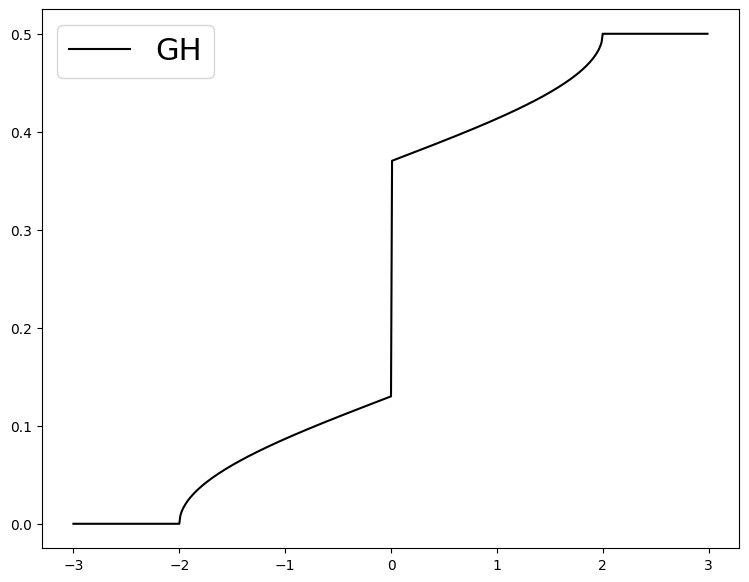

In [36]:
# Re-scaled Local observable 
SIZE=100
position = np.arange(-SIZE,SIZE)
T = 200*np.pi
zeta= position/T # rescaled ray


fig, axes = plt.subplots(1, 1, figsize=(9, 7))
n= np.arange(-3,3,0.01)
M= n_zeta(n,2.5)
axes.plot(n,M, c='black', label='GH')
axes.legend(fontsize=22)



In [75]:
# Example

size = 400
N = 2*size
T1=1
Mu=0
BC= 'open'
C0 = Gamma_0(size)                  # (N,N) dense
vecC0 = mat2vec(C0)                 # (N^2, 1)
h = Hamiltonian(size, T1, Mu, BC)  # (N,N) dense or sparse

# Choose projector
# P_centered = projector_centered_sp(L=size/2, size=size, bc='open', dtype=np.float64)

# or prefix region A = [0, LA-1]:
# P_left = projector_prefix_sp(LA=size, N=N, bc='open')

# or prefix region A= [LA,N]
P_right = projector_prefix_RIGHT_sp(LA= size, N=N, bc= BC)
# Dense_P_right= projector_HZ(size, BC)

#measurement rate
gamma = 1
# h_cond = 1j*h - gamma*P_centered            # NOTE: h_cond is (N,N), keep it sparse if possible
h_cond=  1j*h - gamma*P_right# NOTE: h_cond is (N,N), keep it sparse if possible

# Dense_h_cond= 1j*h - gamma*Dense_P_right
# Build Liouvillian (sparse)
# L_sup = liouvillian_sp(h_cond, P_centered, gamma)

L_sup = liouvillian_sp(h_cond, P_right, gamma)

# Dense_L_sup = liouvillian(Dense_h_cond, Dense_P_right, gamma)
print('done', N)
# P_right.toarray()
home_data = "/Users/juan/Desktop/Bologna/INH_QUENCH/"

done 800


In [38]:
def L_k_spectrum(J, Gamma, k_x, k_y):
    kk_x, kk_y = np.meshgrid(k_x,k_y)
    val= 2j*J*(np.cos(kk_x)-np.cos(kk_y))- Gamma/2
    return val.flatten()

In [374]:
#Liouvillian Spectrum
K_x= (2*np.pi/N)*np.arange(N)
K_y= (2*np.pi/N)*np.arange(N)
evals = LA.eigvals(Dense_L_sup)
Evals_k= L_k_spectrum(T1, gamma,K_x, K_y )
plt.scatter(np.real(evals), np.imag(evals))
# plt.scatter(np.real(Evals_k), np.imag(Evals_k))


In [76]:
# Times
T = np.arange(0, 20*np.pi, 0.5)

# Evolve without dense expm
vecC_t = evolve_vec_expm_multiply(L_sup, vecC0, T)  # shape (len(T), N^2, 1)
print('done with time evolution')

done with time evolution


1

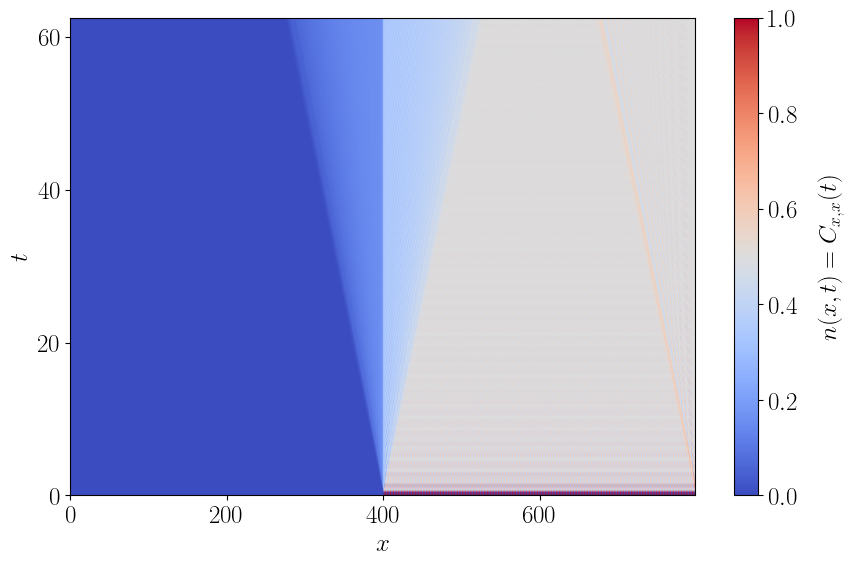

In [193]:
# If you have a time array t of length T (like your earlier code):
fig, ax = plot_density_heatmap(vecC_t, t_axis=T, cmap="coolwarm",vmin=0.0, vmax=1.0, \
                               cbar_label=r"$n(x,t)=C_{x,x}(t)$",yticks=None)
# ax.set_ylim(0,50*np.pi)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 28,
})
# Save the figure as PDF  
home_data = "/Users/juan/Desktop/Bologna/INH_QUENCH/"
ensure_directory_exists(home_data)
# plt.savefig(home_data + f"NE_Transport_{size}_Gamma{gamma}_L{L}.png", format='png', bbox_inches='tight', dpi=300)
# plt.savefig(home_data + f"NE_Transport_{size}_Gamma{gamma}_L{size}_BC_{BC}.png", format='png', bbox_inches='tight', dpi=300)
# plt.savefig(home_data + f"Cent_NE_Trans_{size}_Gamma{gamma}_L{size}_BC_{BC}.png", format='png', bbox_inches='tight', dpi=300)
gamma


In [39]:
# Times
t =10*np.pi

# Evolve without dense expm
vecC_zeta = evolve_vec_single(L_sup, vecC0, t)
print('done with time evolution')


done with time evolution


(800, 800) 1


/Users/juan/venvs/qsim/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/juan/venvs/qsim/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


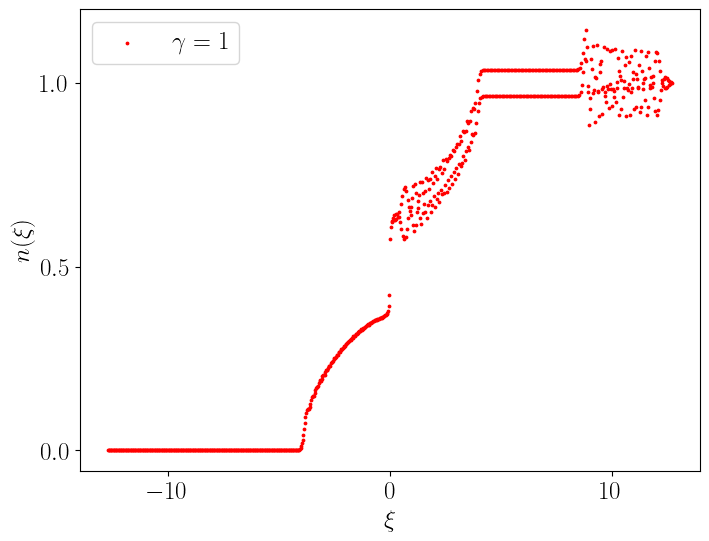

In [77]:
# Re-scaled Local observable 
position = np.arange(-size,size)
zeta= position/t # rescaled ray

C_zeta= vec2mat(vecC_zeta,N)
print(C_zeta.shape, gamma)
vecC_t_zeta_D= np.diag(C_zeta)


fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.scatter(zeta, 2*vecC_t_zeta_D, s=3, c='r', label=rf'$\gamma={gamma}$')
n= np.arange(-3,3,0.01)
# M= n_zeta(n,gamma)
# axes.plot(n,M, c='black', label='GH')
axes.legend(fontsize=22)


axes.set_xlabel(r'$ \xi $')
axes.set_ylabel(r'$n(\xi)$')
plt.legend()
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 28,
})


# plt.savefig(home_data + f"n_GHD_Gamma{gamma}_L{size}_BC_{BC}.png", format='png', bbox_inches='tight', dpi=300)

# plt.savefig(home_data + f"t_{t}_Cent_n_GHD_Gamma{gamma}_L{size}_BC_{BC}.png", format='png', bbox_inches='tight', dpi=300)

In [46]:
# ============================================================
# Local charges
# ============================================================

def _get(C, i, j, bc="pbc"):
    """
    Safe element access with boundary conditions.
    - bc="pbc": indices wrap modulo N
    - bc="obc": out-of-range -> 0
    """
    N = C.shape[0]

    if bc.lower().startswith("p"):    # PBC
        return C[i % N, j % N]

    # OBC
    if 0 <= i < N and 0 <= j < N:
        return C[i, j]

    return 0.0 + 0.0j  # keep complex dtype


def qp(r, x, C, bc="pbc"):
    """ q_plus: C[x, x+r] + C[x+r, x] """
    return _get(C, x, x + r, bc) + _get(C, x + r, x, bc)


def qm(r, x, C, bc="pbc"):
    """ q_minus: i*(C[x, x+r] - C[x+r, x]) """
    return 1j * (_get(C, x, x + r, bc) - _get(C, x + r, x, bc))


def jp(r, x, C, bc="pbc"):
    """
    j_plus: i*( C[x+1, x+r] - C[x, x+r+1]
               + C[x+r+1, x] - C[x+r, x+1] )
    """
    return 1j * (
        _get(C, x + 1,    x + r,     bc)
        - _get(C, x,      x + r + 1, bc)
        + _get(C, x + r + 1, x,      bc)
        - _get(C, x + r,  x + 1,     bc)
    )


def jm(r, x, C, bc="pbc"):
    """
    j_minus: -( C[x+1, x+r] - C[x, x+r+1]
               - C[x+r+1, x] + C[x+r, x+1] )
    """
    return -(
        _get(C, x + 1,    x + r,     bc)
        - _get(C, x,      x + r + 1, bc)
        - _get(C, x + r + 1, x,      bc)
        + _get(C, x + r,  x + 1,     bc)
    )


# ============================================================
# Home directory
# ============================================================

home_data = "/Users/juan/Desktop/Bologna/INH_QUENCH/"




In [47]:
# ============================================================
# Symmetric Local charges
# ============================================================


def qp_symm(r, x, C, bc="pbc"):
    """ q_plus: C[x, x+r] + C[x+r, x] """
    return _get(C, x-r, x + r, bc) + _get(C, x + r, x-r, bc)



def qm_symm(r, x, C, bc="pbc"):
    """ q_minus: i*(C[x, x+r] - C[x+r, x]) """
    return 1j * (_get(C, x-r, x + r+1, bc) - _get(C, x + r+1, x-r, bc))


def jp_symm(r, x, C, bc="pbc"):
    """
    j_plus: i*( C[x+1, x+r] - C[x, x+r+1]
               + C[x+r+1, x] - C[x+r, x+1] )
    """
    return 1j * (
        _get(C, x -r +1,    x + r,     bc)
        - _get(C, x-r,      x + r + 1, bc)
        + _get(C, x + r + 1, x-r,      bc)
        - _get(C, x + r,  x -r + 1,     bc)
    )


def jm_symm(r, x, C, bc="pbc"):
    """
    j_minus: -( C[x+1, x+r] - C[x, x+r+1]
               - C[x+r+1, x] + C[x+r, x+1] )
    """
    return -(
        _get(C, x -r + 1,    x + r+1,     bc)
        - _get(C, x-r,      x + r + 2, bc)
        - _get(C, x + r + 2, x-r,      bc)
        + _get(C, x + r+1,  x -r + 1,     bc)
    )




In [48]:
# ============================================================
# Helpers
# ============================================================

def xi_axis_from_sites(N, t, center=True):
    x = np.arange(N)
    if center:
        x = x - (N - 1) / 2
    return x / t


def split_re_im(y):
    y = np.asarray(y)
    return np.real(y), np.imag(y)


def pretty_axes(ax, xlabel=r'$\zeta$', ylabel=None, legend=True):
    ax.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.6)
    ax.set_xlabel(xlabel, fontsize=25)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=25)
    if legend:
        ax.legend(frameon=True)
    ax.tick_params(axis='both', labelsize=25)
    for spine in ax.spines.values():
        spine.set_alpha(0.6)


# ============================================================
# Matplotlib style
# ============================================================

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18,
})





# ============================================================
# Plot & Save function
# ============================================================

def plot_and_save(r, kind='plus', bc='obc'):
    """
    kind = 'plus'  -> uses qp, jp
    kind = 'minus' -> uses qm, jm
    """
    if kind == 'plus':
        qvals = np.array([qp(r, x, C_zeta, bc) for x in xis])
        jvals = np.array([jp(r, x, C_zeta, bc) for x in xis])
        label_q = rf'$ q^+(\zeta),\ r={r}$'
        label_j = rf'$ J^+(\zeta),\ r={r}$'
        title = rf'$\gamma={gamma}\ q^+(\zeta)$ and $J^+(\zeta)$ (r={r})'
        fname = home_data + f"gamma_{gamma}_chargesANDcurrents_r_{r}_plus.png"

    else:
        center = N // 2   # integer index near the middle

        # pick indices just to the right and left of zeta = 0
        # (you can adjust the offset = 1 or 2 as you like)
        offset = 1
        i_plus  = center + offset
        i_minus = center - offset

        # current jump across the interface (minus to plus)
        j_delta = jm(r, i_plus,  C_zeta, bc) - jm(r, i_minus, C_zeta, bc)

        # local charge at (approx) zeta = 0
        # you can choose center, center+1, or average the two sides
        q_0 = qm(r, center, C_zeta, bc)
        lhs = j_delta
        rhs = r * gamma * q_0
        qvals = np.array([qm(r, x, C_zeta, bc) for x in xis])
        jvals = np.array([jm(r, x, C_zeta, bc) for x in xis])
        label_q = rf'$ q^-(\zeta),\ r={r}$'
        label_j = rf'$ J^-(\zeta),\ r={r}$'
        label_bdy_l = rf'$\Delta J^-={lhs} $'
        label_bdy_r = rf'$r \gamma q^-={rhs} $'
        
        title = rf'$\gamma={gamma}\ q^-(\zeta)$ and $J^-(\zeta)$ (r={r})'
        fname = home_data + f"gamma_{gamma}_chargesANDcurrents_r_{r}_minus.png"

    # Real parts only
    q_re, _ = split_re_im(qvals)
    j_re, _ = split_re_im(jvals)

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    ax.scatter(XIS, q_re, marker='o', s=10, label=label_q)
    ax.scatter(XIS, j_re, marker='o', s=10, c='r', label=label_j)
    pretty_axes(ax, ylabel='')
    ax.set_title(title, fontsize=24)
    fig.tight_layout()
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    plt.close(fig)

    print(f"Saved: {fname}")





In [49]:
# ============================================================
# Plot & Save function Symmetric Charges and Currents
# ============================================================

def plot_and_save_symm(r, kind='plus', bc='obc'):
    """
    kind = 'plus'  -> uses qp_symm, jp_symm
    kind = 'minus' -> uses qm_symm, jm_symm
    """
    if kind == 'plus':
        qvals = np.array([qp_symm(r, x, C_zeta, bc) for x in xis])
        jvals = np.array([jp_symm(r, x, C_zeta, bc) for x in xis])
        label_q = rf'$ q^+(\zeta),\ r={r}$'
        label_j = rf'$ J^+(\zeta),\ r={r}$'
        title = rf'$\gamma={gamma}\ q^+(\zeta)$ and $J^+(\zeta)$ (r={r})'
        fname = home_data + f"SYM_gamma_{gamma}_chargesANDcurrents_r_{r}_plus.png"

    else:
        center = N // 2   # integer index near the middle

        # pick indices just to the right and left of zeta = 0
        # (you can adjust the offset = 1 or 2 as you like)
        offset = 3
        i_plus  = center + offset
        i_minus = center - offset

        # current jump across the interface (minus to plus)
        j_delta = jm_symm(r, i_plus,  C_zeta, bc) - jm_symm(r, i_minus, C_zeta, bc)

        # local charge at (approx) zeta = 0
        # you can choose center, center+1, or average the two sides
        q_0 = qm_symm(r, center, C_zeta, bc)
        lhs = j_delta
        rhs = r * gamma * q_0
        qvals = np.array([qm_symm(r, x, C_zeta, bc) for x in xis])
        jvals = np.array([jm_symm(r, x, C_zeta, bc) for x in xis])
        label_q = rf'$ q^-(\zeta),\ r={r}$'
        label_j = rf'$ J^-(\zeta),\ r={r}$'
        label_bdy_l = rf'$\Delta J^-={lhs} $'
        label_bdy_r = rf'$r \gamma q^-={rhs} $'
        title = rf'$\gamma={gamma}\ q^-(\zeta)$ and $J^-(\zeta)$ (r={r})'
        fname = home_data + f"SYM_gamma_{gamma}_chargesANDcurrents_r_{r}_minus.png"
        # Continuity equation check 
        print(f'q_0={q_0}')
        print("LHS =", lhs)
        print("RHS =", rhs)
        print("LHS - RHS =", lhs - rhs)
        print("|LHS - RHS| / max(1, |RHS|) =", abs(lhs - rhs) / max(1.0, abs(rhs)))

    # Real parts only
    q_re, _ = split_re_im(qvals)
    j_re, _ = split_re_im(jvals)

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    ax.scatter(XIS, q_re, marker='o', s=10, label=label_q)
    ax.scatter(XIS, j_re, marker='o', s=10, c='r', label=label_j)
    pretty_axes(ax, ylabel='')
    ax.set_title(title, fontsize=24)
    fig.tight_layout()
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    plt.close(fig)

    print(f"Saved: {fname}")





In [50]:
# ============================================================
# Data prep
# ============================================================

C_zeta = vec2mat(vecC_zeta, N)
XIS = xi_axis_from_sites(N, t, center=True)
xis = np.arange(N)

In [209]:
# ============================================================
# Loop over r-values
# ============================================================


R_p_list = np.arange(0, 10, 1)   # plus charges and currents
R_m_list = np.arange(0, 10, 1)   # minus charges and currents

for r in R_p_list:
    plot_and_save(r, kind='plus')

for r in R_m_list:
    plot_and_save(r, kind='minus')


Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/gamma_1_chargesANDcurrents_r_0_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/gamma_1_chargesANDcurrents_r_1_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/gamma_1_chargesANDcurrents_r_2_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/gamma_1_chargesANDcurrents_r_3_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/gamma_1_chargesANDcurrents_r_4_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/gamma_1_chargesANDcurrents_r_5_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/gamma_1_chargesANDcurrents_r_6_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/gamma_1_chargesANDcurrents_r_7_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/gamma_1_chargesANDcurrents_r_8_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/gamma_1_chargesANDcurrents_r_9_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/gamma_1_chargesANDcurrents_r_0_minus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/gamma_1

In [203]:
# ============================================================
# Loop over r-values for Symmetric Charges and Currents
# ============================================================


R_p_list = np.arange(0, 10, 1)   # plus charges and currents
R_m_list = np.arange(0, 10, 1)   # minus charges and currents

for r in R_p_list:
    plot_and_save_symm(r, kind='plus')

for r in R_m_list:
    plot_and_save_symm(r, kind='minus')


Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/SYM_gamma_1_chargesANDcurrents_r_0_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/SYM_gamma_1_chargesANDcurrents_r_1_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/SYM_gamma_1_chargesANDcurrents_r_2_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/SYM_gamma_1_chargesANDcurrents_r_3_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/SYM_gamma_1_chargesANDcurrents_r_4_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/SYM_gamma_1_chargesANDcurrents_r_5_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/SYM_gamma_1_chargesANDcurrents_r_6_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/SYM_gamma_1_chargesANDcurrents_r_7_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/SYM_gamma_1_chargesANDcurrents_r_8_plus.png
Saved: /Users/juan/Desktop/Bologna/INH_QUENCH/SYM_gamma_1_chargesANDcurrents_r_9_plus.png
q_0=0j
LHS = 1.3877787807814457e-17j
RHS = 0j
LHS - RHS = 1.3877787807814457e-17j
|LHS - RHS| / max(

In [140]:
# ============================================================
# Video creation from images
# ============================================================

# Install cv2
# import sys
# !{sys.executable} -m pip install opencv-python

import re, glob, cv2

def sorted_by_r(pattern):
    files = glob.glob(pattern)

    def key(fn):
        m = re.search(r"_r_(\d+)_", fn)
        return int(m.group(1)) if m else 1_000_000

    return sorted(files, key=key)
    
    
def images_to_mp4(images, out_path, seconds_per_image=3.0, fps=30):
    assert images, "No images matched!"

    # Load first image to get size
    frame0 = cv2.imread(images[0])
    h, w = frame0.shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(out_path, fourcc, fps, (w, h))

    frames_per_image = int(round(seconds_per_image * fps))

    for fn in images:
        img = cv2.imread(fn)
        if img is None:
            print(f"Warning: could not read {fn}, skipping.")
            continue

        if img.shape[:2] != (h, w):
            img = cv2.resize(img, (w, h), interpolation=cv2.INTER_AREA)

        for _ in range(frames_per_image):
            writer.write(img)

    writer.release()
    print(f"Wrote {out_path}")




In [210]:
# ============================================================
# Build videos
# ============================================================

plus_imgs  = sorted_by_r(home_data + f"gamma_{gamma}_chargesANDcurrents_r_*_plus.png")
minus_imgs = sorted_by_r(home_data + f"gamma_{gamma}_chargesANDcurrents_r_*_minus.png")

images_to_mp4(
    plus_imgs,
    home_data + f"gamma_{gamma}_chargesANDcurrents_plus.mp4",
    seconds_per_image=3.0, fps=30
)

images_to_mp4(
    minus_imgs,
    home_data + f"gamma_{gamma}_chargesANDcurrents_minus.mp4",
    seconds_per_image=3.0, fps=30
)  


Wrote /Users/juan/Desktop/Bologna/INH_QUENCH/gamma_1_chargesANDcurrents_plus.mp4
Wrote /Users/juan/Desktop/Bologna/INH_QUENCH/gamma_1_chargesANDcurrents_minus.mp4


In [58]:
# ============================================================
# Build videos for Symmetric Charges and Currents
# ============================================================

symm_plus_imgs  = sorted_by_r(home_data + f"SYM_gamma_{gamma}_chargesANDcurrents_r_*_plus.png")
symm_minus_imgs = sorted_by_r(home_data + f"SYM_gamma_{gamma}_chargesANDcurrents_r_*_minus.png")

images_to_mp4(
    plus_imgs,
    home_data + f"SYM_gamma_{gamma}_chargesANDcurrents_plus.mp4",
    seconds_per_image=3.0, fps=30
)

images_to_mp4(
    minus_imgs,
    home_data + f"SYM_gamma_{gamma}_chargesANDcurrents_minus.mp4",
    seconds_per_image=3.0, fps=30
)  


Wrote /Users/juan/Desktop/Bologna/INH_QUENCH/SYM_gamma_0.2_chargesANDcurrents_plus.mp4
Wrote /Users/juan/Desktop/Bologna/INH_QUENCH/SYM_gamma_0.2_chargesANDcurrents_minus.mp4


In [52]:

# --- helpers ---------------------------------------------------------------

def xi_axis_from_sites(N, t, center=True):
    x = np.arange(N)
    if center:
        x = x - (N - 1) / 2
    return x / t

def split_re_im(y):
    y = np.asarray(y)
    return np.real(y), np.imag(y)

def two_site_avg(arr, bc="obc"):
    """Average neighboring sites. Returns array with same length as arr."""
    arr = np.asarray(arr)
    out = np.empty_like(arr)
    if bc.lower().startswith("p"):  # PBC: wrap last with first
        out[:] = 0.5 * (arr + np.roll(arr, -1))
    else:  # OBC: last copies itself
        out[:-1] = 0.5 * (arr[:-1] + arr[1:])
        out[-1]  = arr[-1]
    return out

def pretty_axes(ax, xlabel=r'$\zeta$', ylabel=None, legend=True):
    ax.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.6)
    ax.set_xlabel(xlabel, fontsize=25)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=25)
    if legend:
        ax.legend(frameon=True)
    ax.tick_params(axis='both', labelsize=25)
    for spine in ax.spines.values():
        spine.set_alpha(0.6)

# --- matplotlib style ------------------------------------------------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18,
})

# --- data prep -------------------------------------------------------------
C_zeta = vec2mat(vecC_zeta, N)
XIS = xi_axis_from_sites(N, t, center=True)
xis = np.arange(N)

# --- Function to make and save each plot (with two-site average) ----------
def symm_plot_and_save_av(r, kind='plus', bc='obc'):
    """
    kind = 'plus'  -> uses qp_symm, jp_symm
    kind = 'minus' -> uses qm_symm, jm_symm
    Plots the TWO-SITE-AVERAGED real parts.
    """
    if kind == 'plus':
        qvals = np.array([qp_symm(r, x, C_zeta, bc) for x in xis])
        jvals = np.array([jp_symm(r, x, C_zeta, bc) for x in xis])
        label_q = rf'$ q^+(\zeta),\ r={2*r}$'
        label_j = rf'$ J^+(\zeta),\ r={2*r}$'
        title   = rf'$\gamma={gamma}$  two-site avg of $q^+(\zeta)$ and $J^+(\zeta)$ (2r={2*r})'
        fname   = os.path.join(home_data, f"SYM_gamma_{gamma}_chargesANDcurrents_2siteavg_r_{2*r}_plus.png")
        if r==0:
            # pick indices just to the right and left of zeta = 0
            # (you can adjust the offset = 1 or 2 as you like)
            offset = 4
            center = N // 2   # integer index near the middle
            i_plus  = center + offset
            i_minus = center - offset
            q_delta = qp_symm(r, i_plus,  C_zeta, bc) + qp_symm(r, i_minus, C_zeta, bc)
            print(rf'$r \Delta q^+ = {q_delta}$')

        
    else:
        
        center = N // 2   # integer index near the middle

        # pick indices just to the right and left of zeta = 0
        # (you can adjust the offset = 1 or 2 as you like)
        offset = 4
        i_plus  = center + offset
        i_minus = center - offset

        # current jump across the interface (minus to plus)
        j_delta = jm_symm(r, i_plus,  C_zeta, bc) - jm_symm(r, i_minus, C_zeta, bc)

        # local charge at (approx) zeta = 0
        # you can choose center, center+1, or average the two sides
        q_0 = qm_symm(r, center, C_zeta, bc)
        lhs = j_delta
        rhs = -(2*r+1) * gamma * q_0
        qvals = np.array([qm_symm(r, x, C_zeta, bc) for x in xis])
        jvals = np.array([jm_symm(r, x, C_zeta, bc) for x in xis])
        label_q = rf'$ q^-(\zeta),\ 2r+1={2*r+1}$'
        label_j = rf'$ J^-(\zeta),\ 2r+1={2*r+1}$'
        label_bdy_l = rf'$\Delta J^- = {lhs}$'
        label_bdy_r = rf'$r \gamma q^- = {rhs}$'
        title   = rf'$\gamma={gamma}$  two-site avg of $q^-(\zeta)$ and $J^-(\zeta)$ (2r+1={2*r+1})'
        fname   = os.path.join(home_data, f"SYM_gamma_{gamma}_chargesANDcurrents_2siteavg_r_{2*r+1}_minus.png")
        # Continuity equation check 

        print(f'q_0={q_0}')
        print("LHS =", lhs)
        print("RHS =", rhs)
        print("LHS - RHS =", lhs - rhs)
        print("|LHS - RHS| / max(1, |RHS|) =", abs(lhs - rhs) / max(1.0, abs(rhs)))


    # two-site averages (choose bc='obc' or 'pbc')
    qvals_av = two_site_avg(qvals, bc=bc)
    jvals_av = two_site_avg(jvals, bc=bc)

    # Real parts only
    q_re, _ = split_re_im(qvals_av)
    j_re, _ = split_re_im(jvals_av)

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    ax.scatter(XIS, q_re, marker='o', s=10, label=label_q)
    ax.scatter(XIS, j_re, marker='o', s=10, c='r', label=label_j)
    pretty_axes(ax, ylabel='')
    ax.set_title(title, fontsize=24)
    fig.tight_layout()
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved: {fname}")
   
# --- Loop over r-values ----------------------------------------------------

# R_p_list = np.arange(0, 5, 1)   # plus charges and currents
# R_m_list = np.arange(0, 5, 1)   # minus charges and currents

# for r in R_p_list:
#  symm_plot_and_save_av(r, kind='plus',  bc='obc')  # change to 'pbc' if desired

# for r in R_m_list:
#  symm_plot_and_save_av(r, kind='minus', bc='obc')  # change to 'pbc' if desired


In [53]:
center = N // 2  # integer index near the middle

# pick indices just to the right and left of zeta = 0
# (you can adjust the offset = 1 or 2 as you like)
offset = 1
i_plus  = center + offset
i_minus = center - offset
XIS[i_minus],XIS[i_plus]

(np.float64(-0.015915494309189534), np.float64(0.047746482927568605))

In [229]:
# ============================================================
# Build videos for Symmetric Charges and Currents
# ============================================================

symm_plus_imgs  = sorted_by_r(home_data + f"SYM_gamma_{gamma}_chargesANDcurrents_2siteavg_r_*_plus.png")
symm_minus_imgs = sorted_by_r(home_data + f"SYM_gamma_{gamma}_chargesANDcurrents_2siteavg_r_*_minus.png")

images_to_mp4(
    symm_plus_imgs,
    home_data + f"SYM_gamma_{gamma}_chargesANDcurrents_2siteavg_plus.mp4",
    seconds_per_image=3.0, fps=30
)

images_to_mp4(
    symm_minus_imgs,
    home_data + f"SYM_gamma_{gamma}_chargesANDcurrents_2siteavg_minus.mp4",
    seconds_per_image=3.0, fps=30
)  


Wrote /Users/juan/Desktop/Bologna/INH_QUENCH/SYM_gamma_1_chargesANDcurrents_2siteavg_plus.mp4
Wrote /Users/juan/Desktop/Bologna/INH_QUENCH/SYM_gamma_1_chargesANDcurrents_2siteavg_minus.mp4


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

############################################################
# 1. LATTICE CHARGES & CURRENTS
############################################################

# --- your safe get (kept unchanged) ---
def _get(C, i, j, bc="pbc"):
    N = C.shape[0]
    if bc.lower().startswith("p"):  # PBC
        return C[i % N, j % N]
    if 0 <= i < N and 0 <= j < N:
        return C[i, j]
    return 0.0 + 0.0j

def qp(r, x, C, bc="pbc"):
    return _get(C, x, x+r, bc) + _get(C, x+r, x, bc)

def qm(r, x, C, bc="pbc"):
    return 1j * (_get(C, x, x+r, bc) - _get(C, x+r, x, bc))

def jp(r, x, C, bc="pbc"):
    return 1j * (
        _get(C, x+1,   x+r,   bc)
        - _get(C, x,   x+r+1, bc)
        + _get(C, x+r+1, x,   bc)
        - _get(C, x+r,   x+1, bc)
    )

def jm(r, x, C, bc="pbc"):
    return -(
        _get(C, x+1, x+r, bc)
        - _get(C, x, x+r+1, bc)
        - _get(C, x+r+1, x, bc)
        + _get(C, x+r, x+1, bc)
    )






In [100]:


def GHD_vec(sizes, times, R, J1, mu, bc='obc', offset=4):
    """
    Compute numerical errors for three discontinuity conditions as a function
    of system size, with a corresponding time for each size.

    size : Fixed value of half-chain size N= 2*size (can be an array of constant value)
    times : 1D array-like of floats, 
            (e.g. T[i] chosen so \zeta_0^\pm=\pm 1/T[i] gets closer to zero)
    R     : iterable of r values (include r=0 if you want condition 1)
    bc    : boundary condition for qp_symm, qm_symm, jm_symm, etc.
    offset: how far from the interface you sample \zeta→0± (in lattice sites)

    Returns
    -------
    Fst_cond_plus  : shape (len(sizes),)      -- errors for condition 1 (r=0)
    Snd_cond_plus  : shape (len(sizes), nRnz) -- errors for condition 2 (r≠0)
    Trd_cond_minus : shape (len(sizes), len(R)) -- errors for condition 3
    """

    sizes = np.asarray(sizes)
    times = np.asarray(times)
    assert sizes.shape == times.shape, "sizes and times must have same length"

    Fst_cond_plus  = []  # r=0 condition
    Snd_cond_plus  = []  # r>0 condition
    Trd_cond_minus = []  # all r

    R = list(R)
    R_nonzero = [r for r in R if r != 0]

    for s, T in zip(sizes, times):
        N = 2 * s

        # initial state and vectorization for this size
        C0 = Gamma_0(s)        # (N,N)
        vecC0 = mat2vec(C0)    # (N^2,1) or flattened

        # Hamiltonian and projector for this size
        h = Hamiltonian(s, J1, mu, bc)           # (N,N)
        P_right = projector_prefix_RIGHT_sp(LA=s, N=N, bc=bc)
        h_cond = 1j * h - gamma * P_right
        L_sup = liouvillian_sp(h_cond, P_right, gamma)

        # Time evolution at time T for this size
        vecC_t = evolve_vec_single(L_sup, vecC0, T)  # adapt if your function differs
        C_zeta = vec2mat(vecC_t, N)

        # indices around the interface
        center = N // 2
        i_plus  = center + offset
        i_minus = center - offset

        fst_err = None
        snd_errs_r = []
        trd_errs_r = []
        fth_errs_r = []

        for r in R:
            # ---------- Conditions 1 & 2: plus sector ----------
            # symmetric q^+ across interface
            q_delta = qp_symm(r, i_plus, C_zeta, bc) + qp_symm(r, i_minus, C_zeta, bc)

            if r == 0:
                # Condition 1: q_delta - 1 should → 0
                fst_err = q_delta - 1.0
            else:
                # Condition 2: q_delta should → 0
                snd_errs_r.append(q_delta)

            # ---------- Condition 3: minus sector ----------
            # current jump across the interface
            j_delta = jm_symm(r, i_plus, C_zeta, bc) - jm_symm(r, i_minus, C_zeta, bc)
            q_0 = qm_symm(r, center, C_zeta, bc)
            if r ==1 :
                # j^- sum condition
                j_delta_m = jm_symm(r, i_plus, C_zeta, bc) + jm_symm(r, i_minus, C_zeta, bc)
                fth_errs_r.append(j_delta_m + J1**2)
            # local charge at ζ ≈ 0
            

            lhs = j_delta
            rhs = -(2 * r + 1) * gamma * q_0  # your continuity/jump relation
            # rhs = -(2 * r ) * gamma * q_0  # your continuity/jump relation
            
            trd_errs_r.append(lhs - rhs)
            

        if fst_err is not None:
            Fst_cond_plus.append(fst_err)

        Snd_cond_plus.append(snd_errs_r)
        Trd_cond_minus.append(trd_errs_r)
        Fth_cond_minus.append(fth_errs_r)

        print(f"done with time evolution, size={N}, T={T}, offset{offset}")

    Fst_cond_plus  = np.array(Fst_cond_plus)                # (nsizes,)
    Snd_cond_plus  = np.array(Snd_cond_plus, dtype=complex) # (nsizes, nR_nonzero)
    Trd_cond_minus = np.array(Trd_cond_minus, dtype=complex)# (nsizes, len(R))
    Fth_cond_minus = np.array(Fth_cond_minus, dtype = complex) #(nsizes)

    return Fst_cond_plus, Snd_cond_plus, Trd_cond_minus


<>:2: SyntaxWarning: invalid escape sequence '\z'
<>:2: SyntaxWarning: invalid escape sequence '\z'
/var/folders/d9/ht8ll8_j71jdf3whd48h7gww0000gn/T/ipykernel_87628/2326480408.py:2: SyntaxWarning: invalid escape sequence '\z'
  """


In [ ]:
# parameters
 
times = np.array([100, 500, 1000, 5000, 10000, 50000, 100000] ) # => \zeta_0^\pm= \pm 1/times[i] 
sizes = np.array([800]*len(times)) 
R = [0, 1, 2, 3]
OFFSET=1
gamma = 1
T1=1
Mu=0
BC= 'open'



F1, F2, F3 = GHD_vec(sizes, times, R, T1, Mu, bc= BC, offset=OFFSET)

# F1: shape (len(sizes),)   -- first condition (r=0)
# F2: shape (len(sizes), len(R_nonzero)) -- second cond over r != 0
# F3: shape (len(sizes), len(R))         -- third cond over all r


20

OF_2_gamma_1_chi_2_BDY_ERRORS.png


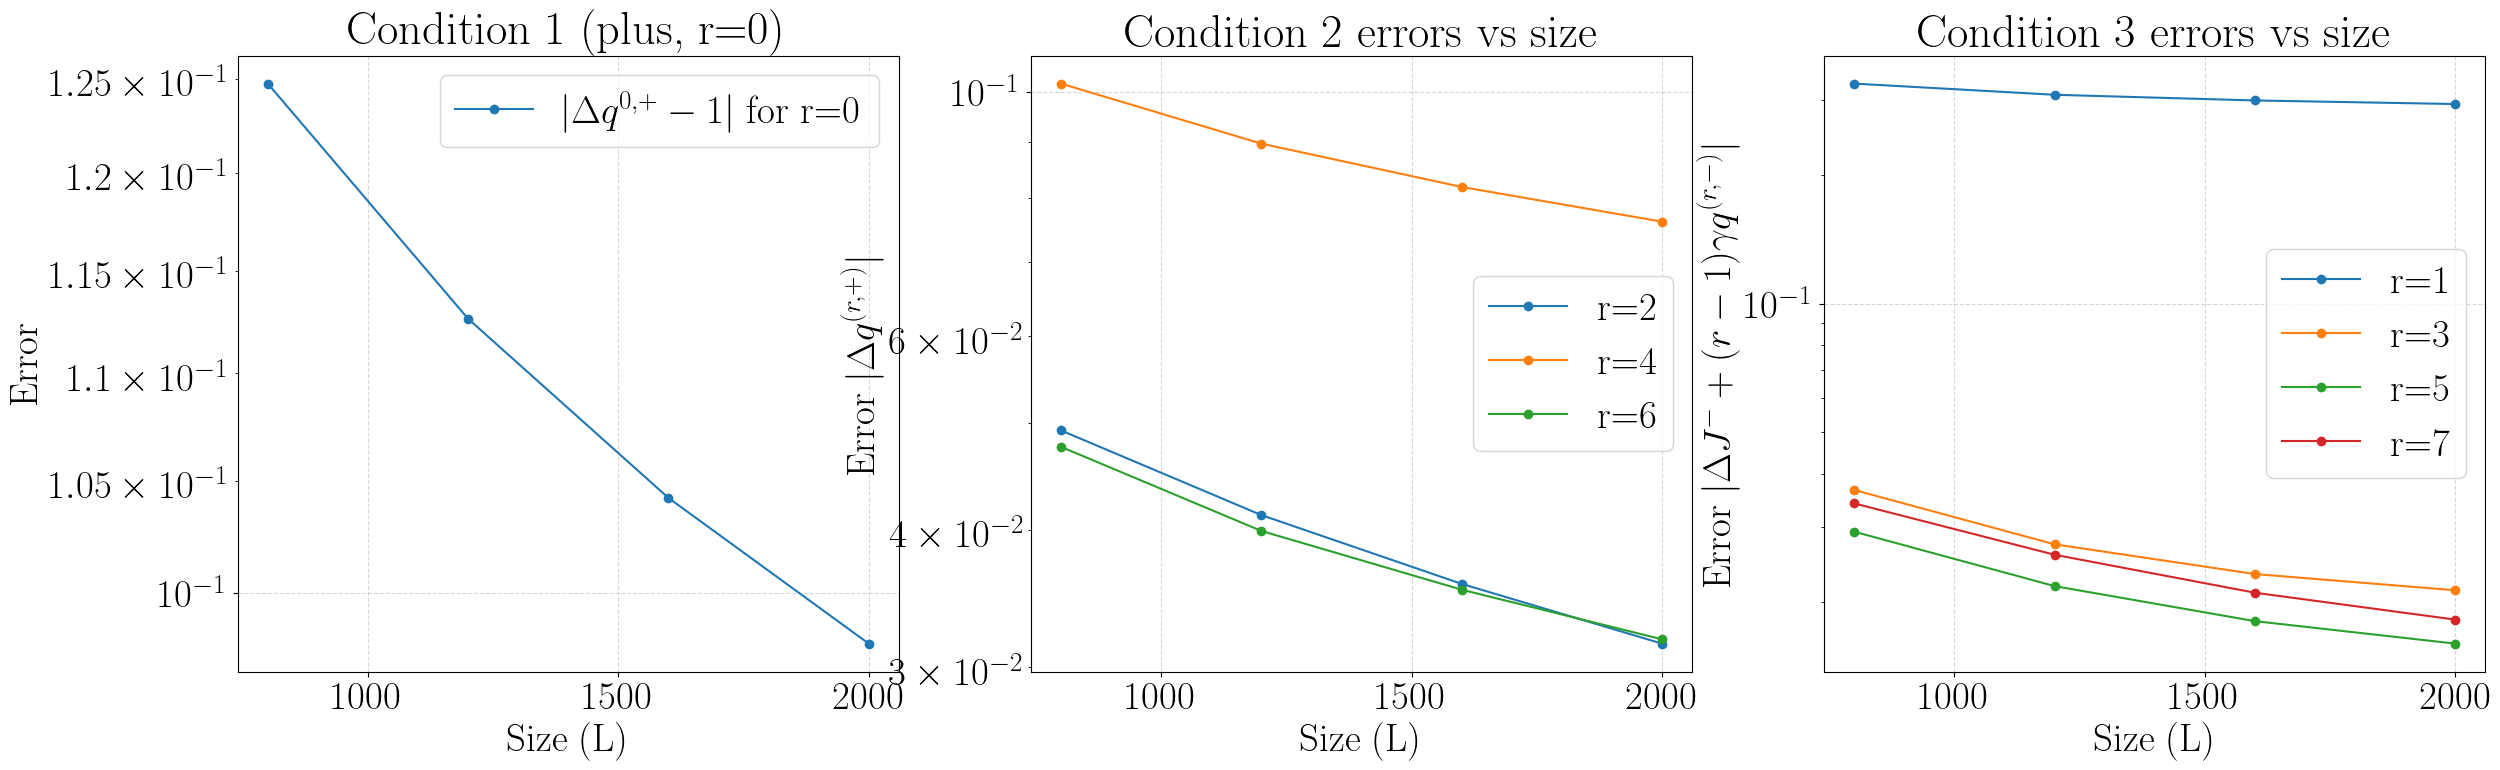

<Figure size 800x500 with 0 Axes>

In [85]:

# reconstruct R_nonzero for plotting
R_nonzero = [r for r in R if r != 0]

# absolute values
err1 = np.abs(F1)                           # shape (nsizes,)
err2_max = np.max(np.abs(F2), axis=1)       # shape (nsizes,)
err3_max = np.max(np.abs(F3), axis=1)       # shape (nsizes,)

fig, axes = plt.subplots(1, 3, figsize=(29, 8), sharex=True)

# --- Condition 1: r=0 ---
axes[0].semilogy(2*sizes, err1, 'o-', label=r'$|\Delta q^{0,+} - 1|$'+' for r=0')
axes[0].set_xlabel('Size (L)')
axes[0].set_ylabel('Error')
axes[0].set_title('Condition 1 (plus, r=0)')
axes[0].grid(True, ls='--', alpha=0.5)
axes[0].legend()

#-- Condition 2: each r separately---
for ir, r in enumerate(R_nonzero):
    axes[1].semilogy(2*sizes, np.abs(F2[:, ir]), 'o-', label=f'r={2*r}')
axes[1].set_xlabel('Size (L)')
axes[1].set_ylabel('Error '+r'$|\Delta q^{(r,+)}|$')
axes[1].set_title('Condition 2 errors vs size')
axes[1].grid(True, ls='--', alpha=0.5)
axes[1].legend()


# -- Condition 3: each r separately --
plt.figure(figsize=(8,5))
for ir, r in enumerate(R):
    axes[2].semilogy(2*sizes, np.abs(F3[:, ir]), 'o-', label=f'r={2*r+1}')
axes[2].set_xlabel('Size (L)')
axes[2].set_ylabel('Error '+r'$ |\Delta J^- + (r-1)\gamma q^{(r,-)}|$')
axes[2].set_title('Condition 3 errors vs size')
axes[2].grid(True, ls='--', alpha=0.5)
axes[2].legend()
name_fig= f"OF_{OFFSET}_gamma_{gamma}_chi_{chi0}_BDY_ERRORS.png"
fig.savefig(  home_data + name_fig)
print(name_fig)

In [339]:
import numpy as np
from scipy.linalg import block_diag

def build_A_B(M, J, gamma):
    """
    Build (A, B) where indices r,j run from -M..M
    A_{r,j} = -2J δ_{j,1-r} - J δ_{j,r-1} + J δ_{j,1+r}
    B_{r,j} = 2 r γ δ_{i,j}
    Returns:
        A, B : (n, n) arrays, with n = 2M+1
    """
    n = 2*M + 1
    A = np.zeros((n, n), dtype=float)
    B = np.zeros((n, n), dtype=float)

    rs = np.arange(-M, M+1)  # r index values

    for i, r in enumerate(rs):
        # diagonal term for B
        B[i, i] = 2.0 * r * gamma

        # off-diagonal structure of A
        for j_idx, j in enumerate(rs):
            if j == 1 - r:
                A[i, j_idx] += -2.0 * J
            if j == r - 1:
                A[i, j_idx] += -1.0 * J
            if j == 1 + r:
                A[i, j_idx] +=  1.0 * J

    return A, B

def build_R_block(M, gamma):
    """
    Build the RHS vector R_r = γ (1 - (-1)^r) / (2 π^2)  for r = -M..M
    Returns:
        R_block : length n = 2M+1
    """
    rs = np.arange(-M, M+1)
    R_block = gamma * (1.0 - (-1.0)**rs) / (2.0 * np.pi**2)
    return R_block

def solve_system(M_trunc, J, gamma):
    """
    High-level function:
      - M_trunc = M (positive integer truncation)
      - J, gamma fixed parameters

    We construct:
      A, B  (size n×n with n=2M+1)
      M_big = (A) ⊕ (B)  (block diagonal 2n×2n)
      R_big = (R_block)   (length 2n)
    and solve M_big N = R_big.

    Returns:
        rs        : array of r values in [-M, M]
        a_minus   : solution components a^-_r
        b_part    : solution components b_r (your "b^-_r" or "b^+_r")
    """
    M = M_trunc
    n = 2*M + 1

    # Build A and B
    A, B = build_A_B(M, J, gamma)
   
    # Build big block matrix M = (A) ⊕ (B)
    M_big = block_diag(A,B)  # shape (2n, 2n)

    # Build RHS vector 
    R_block = build_R_block(M, gamma)   # length n
    R_big = 1/2*np.eye(2*n)*np.concatenate([R_block, R_block])  # length 2n

    # Solve M_big N = R_big.
    # In case M_big is singular or ill-conditioned, you can switch to lstsq.
    try:
        N = np.linalg.solve(M_big, R_big)
    except np.linalg.LinAlgError:
        # fall back to least-squares solution
        N, *_ = np.linalg.lstsq(M_big, R_big, rcond=None)

    # Split into a^- and b^+ parts
    a_minus = N[:n]
    b_part  = N[n:]   # the part proportional to b^+_r

    rs = np.arange(-M, M+1)

    return b_part

# ------------------ Example usage ------------------
if __name__ == "__main__":
    M_trunc = 10   # truncation
    J = 1.0
    gamma = 1

    b_vec = solve_system(M_trunc, J, gamma)

    # Now b_vec[r_index] is the coefficient for r = rs[r_index]
#     print("r values:", rs)
    print("b_r (part of N you care about):")
    print(b_vec.shape)



b_r (part of N you care about):
(21, 42)


START!
Saved ./compare_r2_sign+.png


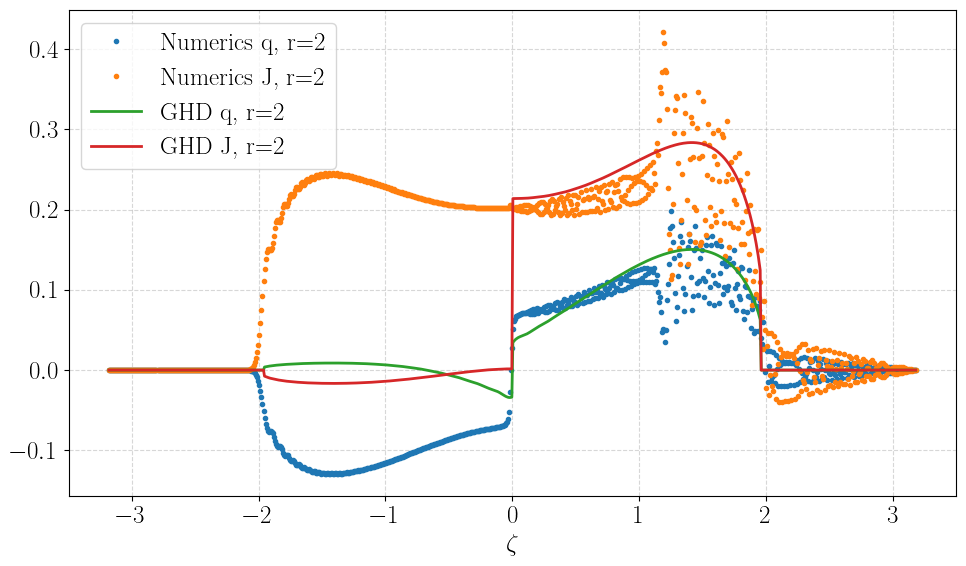

start with time evolution
evolve_vec_single took 0.51 min
done with time evolution
Done with charge calculation
Done with current calculation
Saved /Users/juan/Desktop/Bologna/INH_QUENCH/compare_r1_sign-.png
compare_lattice_vs_ghd took 36.07 min


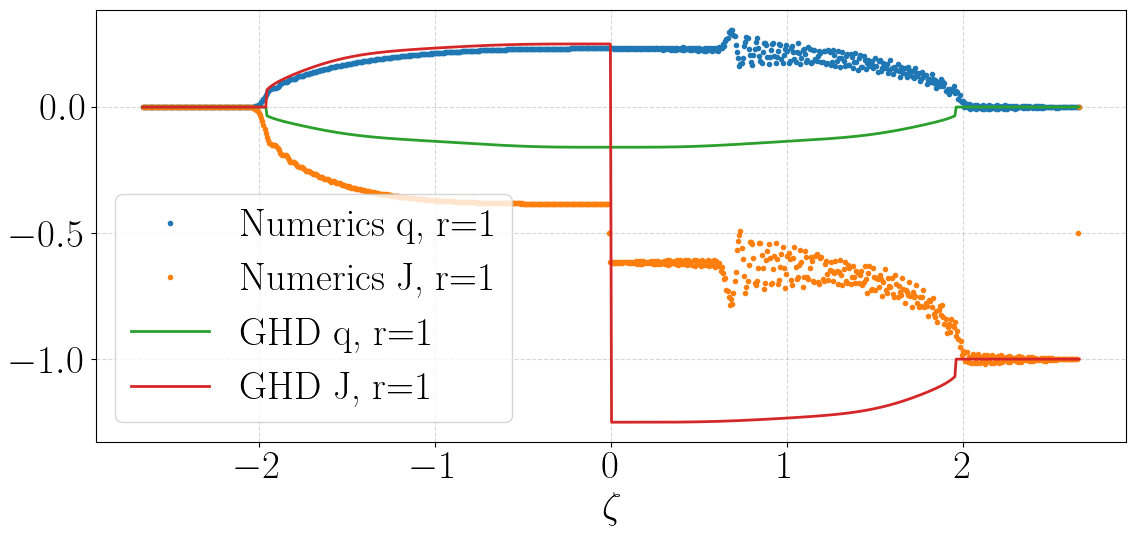

In [418]:
import time

def timed_call(func, *args, **kwargs):
    start = time.perf_counter()
    result = func(*args, **kwargs)
    end = time.perf_counter()
    print(f"{func.__name__} took {(end - start)/60:.2f} min")
    return result



if __name__ == "__main__":
    size= 400
    N=2*size
    t= 150
    M = 10
    J = 1.0
    Mu=0
    gamma = 1
    r=1
    BC= 'open'
    
    #initial state
    C0 = Gamma_0(size)                  # (N,N) dense
    vecC0 = mat2vec(C0)                 # (N^2, 1)
    
    # system Hamiltonian
    h = Hamiltonian(size, J, Mu, BC)  # (N,N) dense or sparse
    
    # or prefix region A= [LA,N]
    P_right = projector_prefix_RIGHT_sp(LA= size, N=N, bc= BC)
    
    # h_cond = 1j*h - gamma*P_centered            # NOTE: h_cond is (N,N), keep it sparse if possible
    h_cond=  1j*h - gamma*P_right# NOTE: h_cond is (N,N), keep it sparse if possible
    L_sup = liouvillian_sp(h_cond, P_right, gamma)
    
    # time evolution of the covariance matrix
    print('start with time evolution')
    vecC_zeta = timed_call(evolve_vec_single,L_sup, vecC0, t)
    print('done with time evolution')
    C_zeta =vec2mat(vecC_zeta, N)
    
    #home directory
    home_data = "/Users/juan/Desktop/Bologna/INH_QUENCH/"
    
    #GHD calculation
    q_VALS,J_VALS=timed_call(compare_lattice_vs_ghd,C_zeta, N, t, r, sign='-', bc='obc', r_max_chi=10)

    

In [414]:
# # plot
# q_lat = np.real([qp(r, xx, C_zeta, bc) for xx in range(N)])
# J_lat = np.real([jp(r, xx, C_zeta, bc) for xx in range(N)])

# q_lat = two_site_avg(q_lat, bc)
# J_lat = two_site_avg(J_lat, bc)
# plt.figure(figsize=(12, 6))
# plt.plot(XIS, -q_VALS, 'o', ms=3, label=f"GHD q, r={r}")
# plt.plot(XIS, -J_VALS, 'o', ms=3, label=f"GHD J, r={r}")
# plt.plot(XIS, q_lat, '-', lw=2, label=f"Numerics q, r={r}")
# plt.plot(XIS, J_lat, '-', lw=2, label=f"Numerics J, r={r}")
# plt.xlabel(r"$\zeta$")
# plt.grid(True, ls='--', alpha=0.5)
# plt.legend()
# plt.tight_layout()
# fn = home_data + f"compare_r{r}_sign{sign}.png"
   
